In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

In [34]:
aapl = pd.read_csv("/content/AAPL_2006-01-01_to_2018-01-01.csv")
cat = pd.read_csv("/content/CAT_2006-01-01_to_2018-01-01.csv")
jpm = pd.read_csv("/content/JPM_2006-01-01_to_2018-01-01.csv")
mcd = pd.read_csv("/content/MCD_2006-01-01_to_2018-01-01.csv")
wmt = pd.read_csv("/content/WMT_2006-01-01_to_2018-01-01.csv")

In [3]:
aapl.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
1,2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2,2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
3,2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
4,2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL


In [ ]:
aapl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3019 entries, 0 to 3018
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3019 non-null   object 
 1   Open    3019 non-null   float64
 2   High    3019 non-null   float64
 3   Low     3019 non-null   float64
 4   Close   3019 non-null   float64
 5   Volume  3019 non-null   int64  
 6   Name    3019 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 165.2+ KB


Let's check the shape of the each subdataset

In [ ]:
print("Apple subdataset shape:", aapl.shape)
print("Caterpillar subdataset shape:", cat.shape)
print("JP Morgan subdataset shape:", jpm.shape)
print("McDonald subdataset shape:", mcd.shape)
print("Walmart subdataset shape:", wmt.shape)

Apple subdataset shape: (3019, 7)
Caterpillar subdataset shape: (3020, 7)
JP Morgan subdataset shape: (3020, 7)
McDonald subdataset shape: (3020, 7)
Walmart subdataset shape: (3020, 7)


We notice that all subdatasets (except Apple) have 3020 rows and 7 columns. This indicate that the same measurements were recorded over a similar length of period of times. **Now, Let's combine all the 5 subdatasets into 1 single dataset.**

In [4]:
stocks = pd.concat(
    [aapl, cat, jpm, mcd, wmt],
    ignore_index=True
)

In [ ]:
stocks.shape

(15099, 7)

Let's start by saving this unprocessed dataset on my drive and download it locally

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
stocks.to_csv("stocks_dataset.csv", index=False)
from google.colab import files
files.download("stocks_dataset.csv")

Let's sort the dataset by the date and the stock names, and then convert the **date** column in the **datetime** datatype.

In [5]:
stocks = stocks.sort_values(["Date", "Name"], ignore_index=True)

In [ ]:
stocks.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
1,2006-01-03,57.87,58.11,57.05,57.80,3697500,CAT
2,2006-01-03,39.83,40.36,39.30,40.19,12839400,JPM
3,2006-01-03,34.29,34.29,33.20,33.52,9250100,MCD
4,2006-01-03,46.36,46.66,45.57,46.23,23413900,WMT


In [6]:
stocks["Date"].dtype

dtype('O')

In [7]:
stocks["Date"] = pd.to_datetime(stocks["Date"])
stocks["Date"].dtype

dtype('<M8[ns]')

## A. Understanding the Dataset

To understand the data, let's start by checking if the dataset has any Null value

In [8]:
stocks[stocks.isnull().any(axis=1)]

,Date,Open,High,Low,Close,Volume,Name
14565,2017-07-31,NaN,NaN,NaN,113.95,4486013,CAT
14566,2017-07-31,NaN,92.36,NaN,91.80,11520329,JPM
14567,2017-07-31,NaN,NaN,154.85,155.14,4280364,MCD
14568,2017-07-31,NaN,NaN,NaN,79.99,6263189,WMT


We notice that the columns 'High' and 'Low' have 3 null values, and the column 'Open' has 4 null values.
<br>Because the number of rows containg null values in very negligeable (4 out of 15000), I've decided to drop them.

In [9]:
stocks.dropna(inplace=True)
stocks[stocks.isnull().any(axis=1)]

,Date,Open,High,Low,Close,Volume,Name


After cleaning the data, let's now calculate metrics such as the datset timeline, the number of observation, the dataset granularity, etc.

In [10]:
dmin = stocks['Date'].min()
dmax = stocks['Date'].max()
print(f"The time range of the datset expands form {dmin.date()} to {dmax.date()}")

The time range of the datset expands form 2006-01-03 to 2017-12-29


In [11]:
nb_obs = stocks.shape
nb_stocks = stocks['Name'].nunique()
name_stocks = stocks['Name'].unique()

print(f"The dataset comprises {nb_obs[0]} observations, within {nb_stocks} stocks whitch are: {name_stocks}")

The dataset comprises 15095 observations, within 5 stocks whitch are: ['AAPL' 'CAT' 'JPM' 'MCD' 'WMT']


In [12]:
stocks.groupby("Name")["Date"].diff().value_counts()

,count
Date,
1 days,11830
3 days,2721
4 days,393
2 days,135
5 days,11


The most frequent trading pattern observed is a **1-day gap**, which signifies consecutive daily trading sessions. The next most common gap is **3 days**, typically indicating a weekend between Friday and Monday's trading data.

Frequencies also show **4-day gaps**, often suggesting an extended weekend due to a public holiday, and **2-day gaps**, which occur when markets are closed for a mid-week holiday.

The rarest occurrences are **5-day gaps**, likely reflecting longer market closures such as during winter holidays.

In [ ]:
stocks.describe()

,Date,Open,High,Low,Close,Volume
count,15095,15095.000000,15095.000000,15095.000000,15095.000000,1.509500e+04
mean,2012-01-01 02:58:40.582974464,68.646401,69.255139,68.018154,68.653909,3.711620e+07
min,2006-01-03 00:00:00,7.390000,7.560000,7.170000,7.240000,1.775920e+05
25%,2008-12-31 00:00:00,47.630000,48.070000,47.165000,47.645000,6.199546e+06
50%,2011-12-29 00:00:00,65.110000,65.750000,64.460000,65.170000,1.129066e+07
75%,2014-12-31 00:00:00,87.600000,88.230000,86.765000,87.490000,3.007722e+07
max,2017-12-29 00:00:00,175.110000,177.200000,174.860000,176.420000,8.432640e+08
std,NaN,30.168165,30.296953,30.043208,30.180016,6.685918e+07


The `stocks.describe()` output provides key statistical insights into the dataset:

*   **Date Range**: The data spans from January 3, 2006, to December 29, 2017, covering approximately 12 years of trading information.
*   **Price Columns (Open, High, Low, Close)**: These columns show a wide range of values. The significant price fluctuations and large standard deviations (around 30) for these columns are indicative of the diverse price points and volatility across the different companies included in the dataset.
*   **Volume**: The trading volume also demonstrates a vast range, from a minimum of 177,592 to a maximum of 843,264,000, with an average of approximately 37.1 million. The very high standard deviation (66.8 million) is particularly notable because it reflects the aggregation of stocks from different industries. For example, a high-volume stock like Apple will have significantly different trading activity compared to a lower-volume stock like Caterpillar, leading to this large overall variation when combined.

## B. Analytical Questions

In [ ]:
pivot = stocks.pivot(
    index="Date",
    columns="Name",
    values=["Close","High","Volume"]
)

In [ ]:
pivot.head()

Close                               High                       \
Name         AAPL    CAT    JPM    MCD    WMT   AAPL    CAT    JPM    MCD   
Date                                                                        
2006-01-03  10.68  57.80  40.19  33.52  46.23  10.68  58.11  40.36  34.29   
2006-01-04  10.71  59.27  39.62  33.82  46.32  10.85  59.43  40.14  33.85   
2006-01-05  10.63  59.27  39.74  33.86  45.69  10.70  59.86  39.81  34.20   
2006-01-06  10.90  60.45  40.02  34.06  45.88  10.96  60.76  40.24  34.30   
2006-01-09  10.86  61.55  40.67  34.71  45.71  11.03  61.68  40.72  34.74   

                        Volume                                                
Name          WMT         AAPL        CAT         JPM        MCD         WMT  
Date                                                                          
2006-01-03  46.66  201853036.0  3697500.0  12839400.0  9250100.0  23413900.0  
2006-01-04  46.50  155225609.0  4577200.0  13491800.0  5990300.0  14090700.0  
2006-01-05  46.40  112396081.0  4590700.0   8109400.0  6245200.0  20759200.0  
2006-01-06  45.88  176139334.0  5692300.0   7966900.0  5877100.0  21135000.0  
2006-01-09  46.15  168861224.0  4409300.0  16575200.0  4659900.0  14890700.0

Let's first start by visualizing the evolution of all the 5 stocks, from 2006 to 2018.

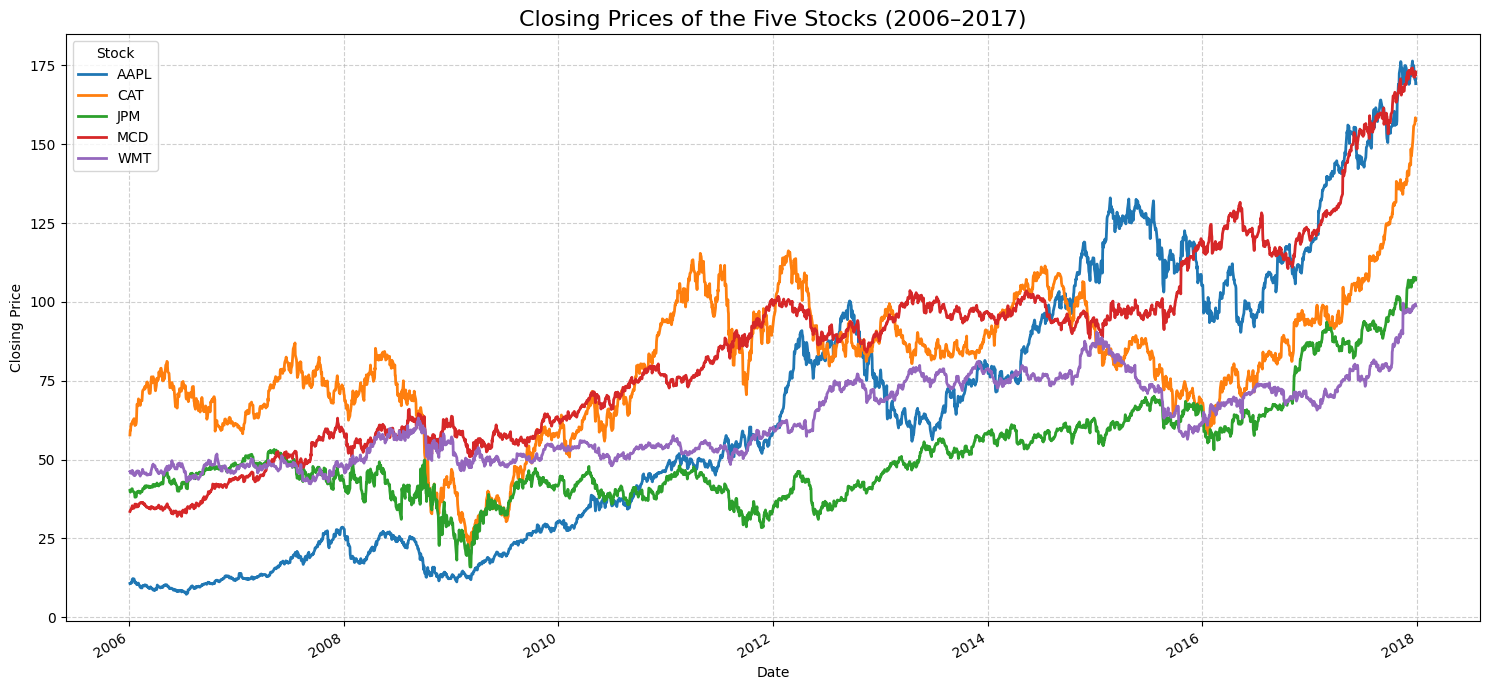

In [ ]:
# Plot the 'Close' column of the 'pivot' dataset.
pivot['Close'].plot(figsize=(15, 7), linewidth=2)

plt.title('Closing Prices of the Five Stocks (2006–2017)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Stock')
plt.tight_layout()

plt.show()

The visualization demonstrates that all the five stocks experienced *positive long-term growth* between 2006 and 2017, though with varying degrees of volatility and appreciation. **Apple** exhibited the strongest overall growth but also one of the highest levels of volatility. **McDonald's** showed steady and consistent appreciation, while **Walmart** remained the most stable stock throughout the period. **Caterpillar** and **JPMorgan** displayed greater cyclical behavior, with noticeable declines and recoveries.
<br>The common downturn around 2008–2009 affected all five stocks. It highlights the influence of broader market conditions ( in this case **the 2008 subprime morgage crisis**) on individual stock performance.

Now let's indentify which stock is the most volatile.

In [ ]:
volatility = stocks.groupby("Name")["Close"].std().sort_values(ascending=False)
print(volatility)

Name
AAPL    44.536448
MCD     31.018593
CAT     20.940414
JPM     16.341080
WMT     12.745512
Name: Close, dtype: float64


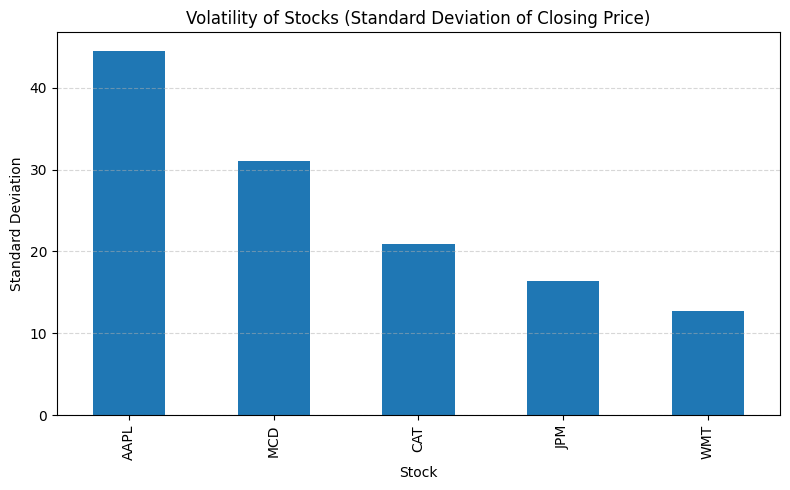

In [ ]:
plt.figure(figsize=(8,5))
volatility.plot(kind='bar')

plt.title("Volatility of Stocks (Standard Deviation of Closing Price)")
plt.xlabel("Stock")
plt.ylabel("Standard Deviation")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The bar chart illustrating 'Volatility of Stocks' clearly shows varying price fluctuations among the companies. Standard deviation indicates volatility: higher values mean greater price swings and risk, while lower values suggest stability. **Apple (AAPL)** is significantly the most volatile stock, reflecting its dynamic growth. In contrast, **Walmart (WMT)** is the least volatile, indicative of a stable, defensive company. **McDonald's (MCD)**, **Caterpillar (CAT)**, and **JP Morgan (JPM)** exhibit moderate volatility, highlighting diverse risk profiles across these companies and sectors.

Now, let's look at what is the correlation of the stocks? Do they move together?

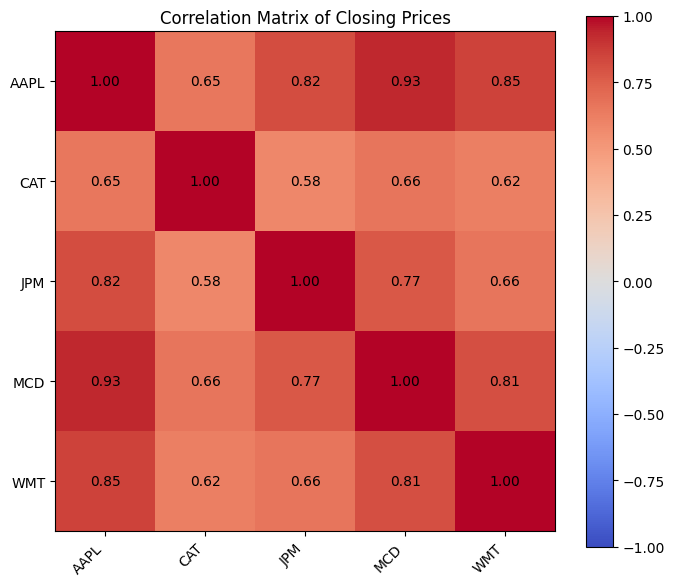

In [ ]:
corr = pivot["Close"].corr()

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Display correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j,i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(im)
plt.title("Correlation Matrix of Closing Prices")

plt.tight_layout()
plt.show()

The 'Correlation Matrix of Closing Prices' visualizes the linear relationship between the daily closing prices of the five stocks. Correlation coefficients range from -1 to 1:
*   **1** indicates a perfect positive linear relationship (stocks move in the same direction).
*   **-1** indicates a perfect negative linear relationship (stocks move in opposite directions).
*   **0** indicates no linear relationship.

From the matrix, we observe several key points:

1.  **Generally Positive Correlations**: All correlation coefficients are positive, ranging from approximately 0.58 to 0.93. This indicates that, over the period, all these stocks generally tend to move in the same direction. When one stock's price increases, others are also likely to increase, and vice-versa, which is typical for stocks within the same market.

2.  **Strongest Correlations**: **Apple (AAPL)** shows very strong positive correlations with **McDonald's (MCD)** (0.93) and **Walmart (WMT)** (0.85). This suggests that these pairs of stocks often experience similar price movements, likely influenced by broad market trends or consumer spending patterns. **JP Morgan (JPM)** also has a strong correlation with Apple (0.82).

3.  **Weaker, Yet Positive, Correlations**: **Caterpillar (CAT)** generally has the weakest, though still positive, correlations with the other stocks. Its lowest correlation is with **JP Morgan (JPM)** (0.58) and **Walmart (WMT)** (0.62). This might suggest that Caterpillar's stock performance is somewhat less tied to the specific factors influencing the other, more consumer-oriented or tech-focused companies, possibly due to its industrial nature.

4.  **Implications**: High positive correlations imply limited diversification benefits when these stocks are held together in a portfolio, as they tend to rise and fall in unison. Conversely, weaker positive correlations, like those involving Caterpillar, might offer slightly better diversification, as their movements are not as tightly coupled with the others. The widespread positive correlation also highlights the pervasive influence of broader economic conditions and market sentiment on individual stock prices.

Let's now respond to the question: **How does yesterday's closing price influence today's closing price?**

In [14]:
stocks["Lag1"] = (
    stocks.groupby("Name")["Close"]
          .shift(1)
)

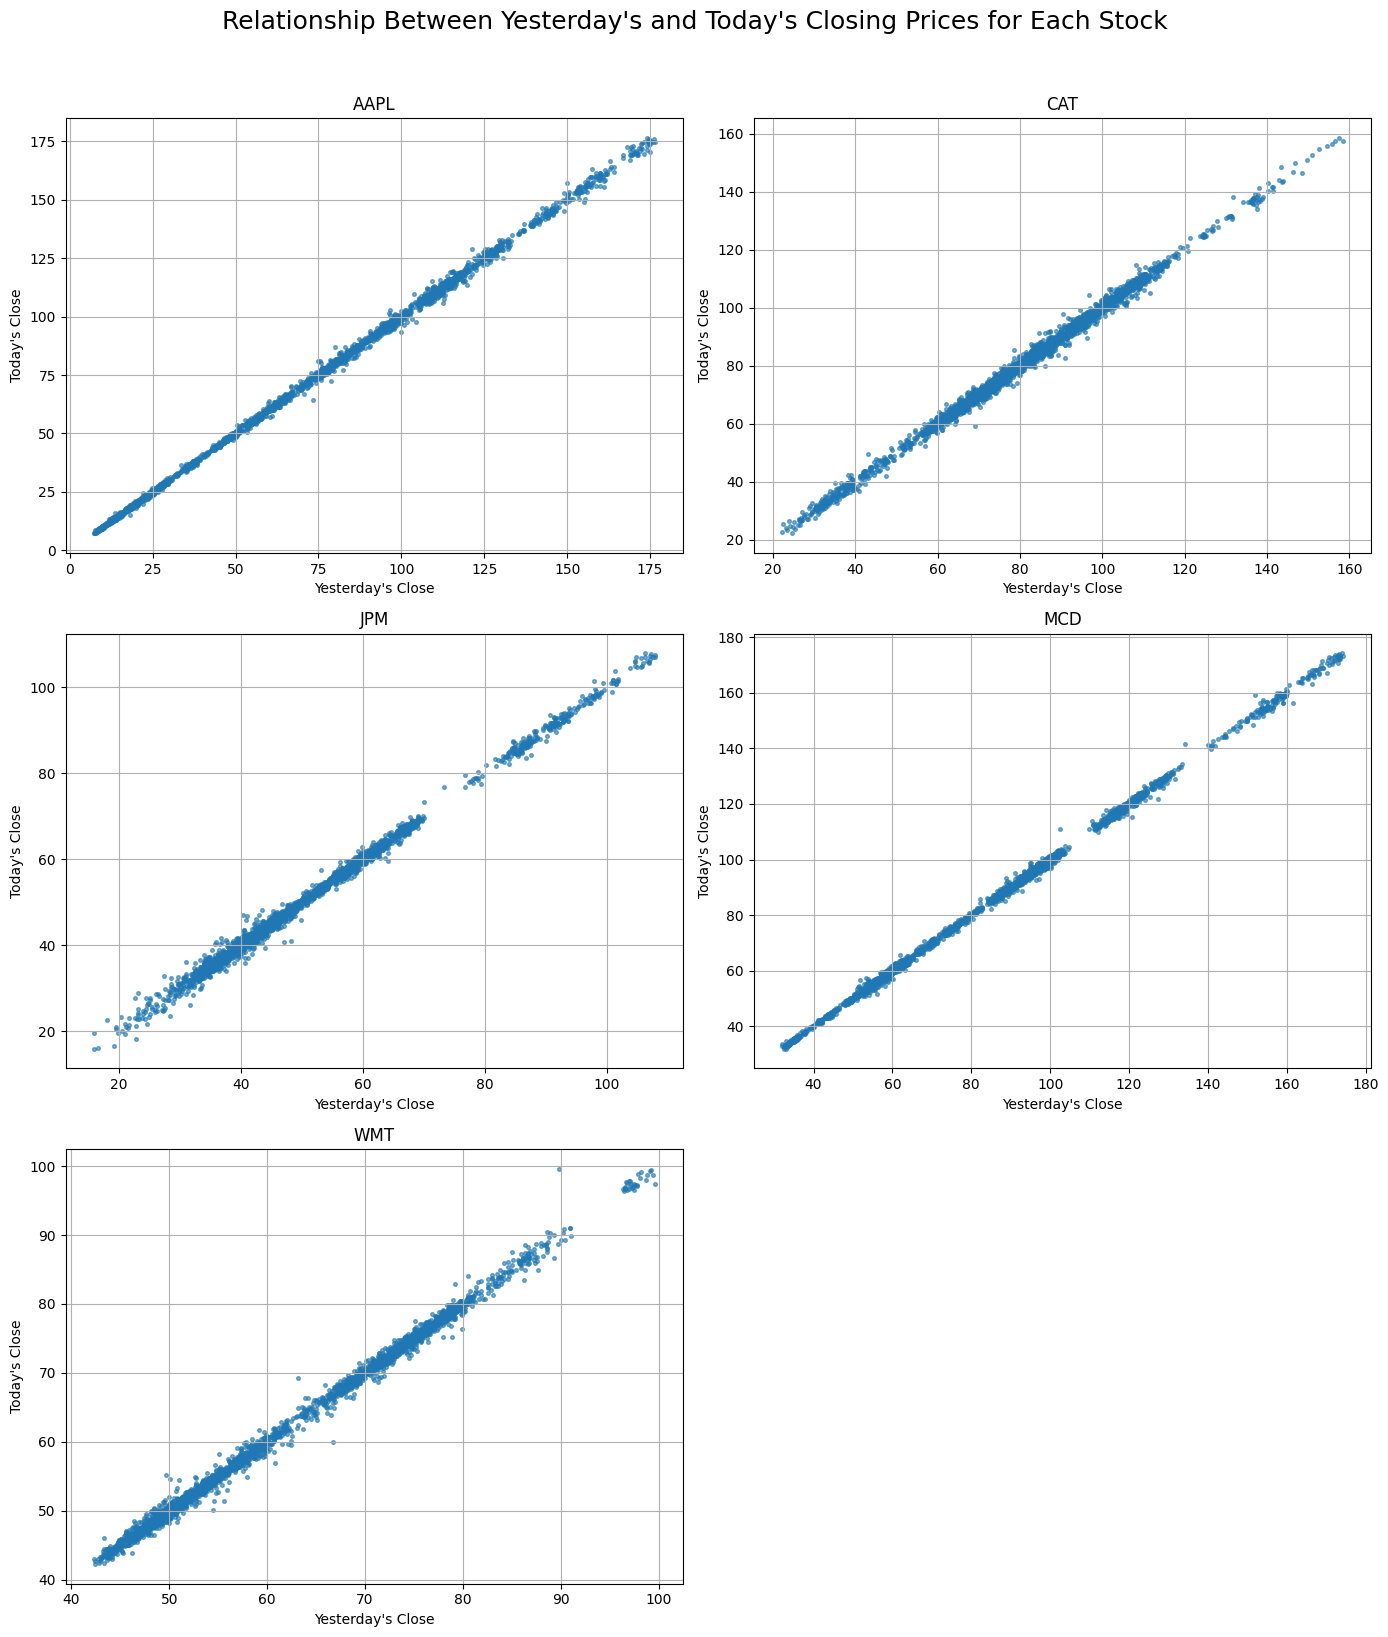

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

stock_names = stocks["Name"].unique()

for i, stock in enumerate(stock_names):
    stock_data = stocks[stocks["Name"] == stock]

    axes[i].scatter(stock_data["Lag1"], stock_data["Close"], alpha=0.6, s=7)

    axes[i].set_title(stock)
    axes[i].set_xlabel("Yesterday's Close")
    axes[i].set_ylabel("Today's Close")
    axes[i].grid(True)

# Remove the last empty subplot
fig.delaxes(axes[5])

fig.suptitle(
    "Relationship Between Yesterday's and Today's Closing Prices for Each Stock",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

The scatter plots reveal a strong positive linear relationship between **yesterday's closing price and today's closing price** for all five stocks (AAPL, CAT, JPM, MCD, and WMT). In each subplot, the observations are tightly clustered along the diagonal line, indicating that consecutive daily closing prices are highly correlated and that stock prices change gradually rather than abruptly from one trading day to the next.

Although the price ranges differ across the five companies, the consistent linear pattern suggests that each stock exhibits strong temporal dependence **(positive autocorrelation)**, where the previous day's closing price is a reliable indicator of the current day's closing price. Minor deviations from the diagonal represent normal day-to-day market fluctuations, but these are relatively small compared to the overall trend.

These findings demonstrate that lagged features, such as the previous day's closing price (Lag1), contain valuable predictive information and should be included as input variables in the forecasting models developed later in this analysis.

Next, let's look at another common analyses in financial time series, the **7-day moving average (MA7)**, which is the average closing price over the previous 7 trading days.
<br>So, here the question we'll be answering is *"How does the 7-day MA compare with the actual closing price?"*
<br>N.B. We are going to use specifically the **apple stock.**

In [16]:
stocks["MA7"] = (
    stocks.groupby("Name")["Close"]
          .transform(lambda x: x.rolling(7).mean())
)

/tmp/ipykernel_566/3493833545.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


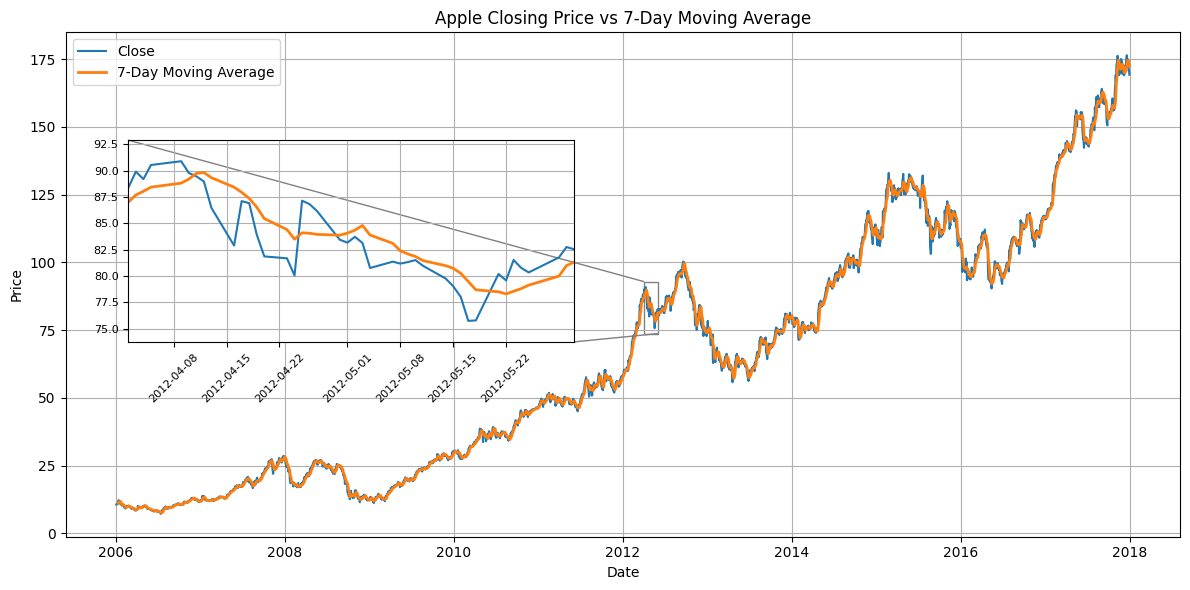

In [ ]:
aapl = stocks[stocks["Name"]=="AAPL"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(aapl["Date"], aapl["Close"], label="Close")
ax.plot(aapl["Date"], aapl["MA7"], linewidth=2, label="7-Day Moving Average")

ax.set_title("Apple Closing Price vs 7-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True)

# -------------------------
# Zoomed inset (April-May 2012)
# -------------------------
axins = inset_axes(ax,
                   width="40%",
                   height="40%",
                   loc="upper left",
                   bbox_to_anchor=(0.05, -0.2, 1, 1),
                   bbox_transform=ax.transAxes)

zoom = aapl[
    (aapl["Date"] >= "2012-04-01") &
    (aapl["Date"] <= "2012-05-31")
]

axins.plot(zoom["Date"], zoom["Close"])
axins.plot(zoom["Date"], zoom["MA7"], linewidth=2)

# Match inset limits to the selected period
axins.set_xlim(zoom["Date"].min(), zoom["Date"].max())
axins.set_ylim(
    zoom[["Close", "MA7"]].min().min() - 2,
    zoom[["Close", "MA7"]].max().max() + 2
)

axins.tick_params(axis='x', rotation=45, labelsize=8)
axins.tick_params(axis='y', labelsize=8)
axins.grid(True)

# Draw connectors between inset and main plot
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="gray")

plt.tight_layout()
plt.show()

The comparison between Apple's daily closing price and its **7-day moving average** shows that the moving average successfully smooths short-term price fluctuations while preserving the stock's overall trend. <br>Although the moving average closely follows the daily closing price, it responds more slowly to sudden increases and decreases because it is calculated as the average of the previous seven trading days.

The zoomed view of **April–May 2012** clearly illustrates this behaviour, showing that the moving average filters out daily market noise and lags slightly behind the actual closing price during periods of rapid change. This smoothing effect makes the underlying trend easier to identify and demonstrates why moving averages are widely used as informative features in time-series forecasting models.

Now, let's talk about the last analytical question: **Which stock provides the highest average daily return?**

In [17]:
stocks["Return"] = (
    stocks.groupby("Name")["Close"]
          .pct_change()
)

returns = (
    stocks.groupby("Name")["Return"]
          .mean()
          .mul(100)   # Convert to percentage
          .sort_values(ascending=False)
)

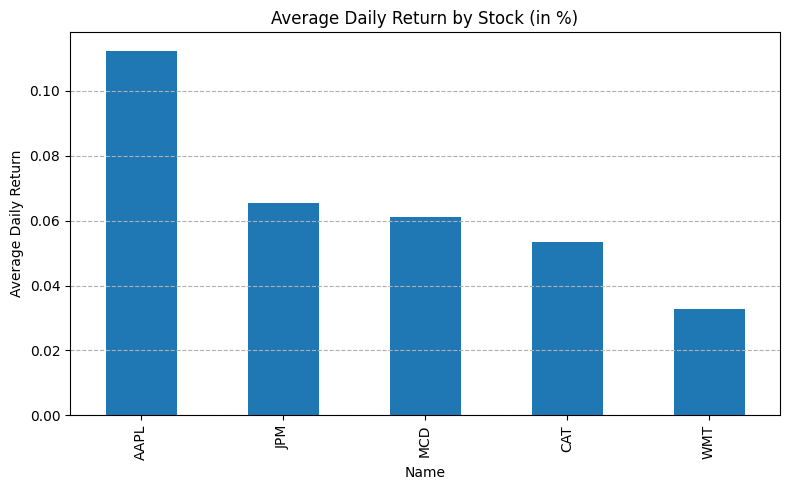

In [ ]:
returns.plot(kind="bar", figsize=(8,5))

plt.title("Average Daily Return by Stock (in %)")
plt.ylabel("Average Daily Return")
plt.grid(axis="y", linestyle="--")
plt.tight_layout()

plt.show()

The bar chart displaying the 'Average Daily Return by Stock (in %)' provides insight into the typical daily performance of each company's stock over the analyzed period.

Key observations from the chart are:

*   **Apple (AAPL)** exhibits the highest average daily return, indicating that on an average day, Apple's stock price increased the most relative to its previous day's close among the selected stocks. This aligns with its higher volatility and significant growth observed earlier.
*   **JPMorgan (JPM)** and **McDonald's (MCD)** show moderate average daily returns, positioning them in the middle of the pack. Their returns are positive but less pronounced than Apple's.
*   **Caterpillar (CAT)** also shows a positive, but slightly lower, average daily return compared to JPM and MCD.
*   **Walmart (WMT)** has the lowest average daily return among the five stocks. This is consistent with its earlier identification as the least volatile stock, suggesting a more stable but slower-growing investment.

In summary, the chart reinforces the varying growth profiles of these companies, with higher average daily returns generally correlating with stocks that demonstrated higher growth and volatility, while lower returns correspond to more stable, less volatile assets.

## Machine Learning Models

In [ ]:
stocks.head()

,Date,Open,High,Low,Close,Volume,Name,Lag1,MA7,Return
0,2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL,NaN,NaN,NaN
1,2006-01-03,57.87,58.11,57.05,57.80,3697500,CAT,NaN,NaN,NaN
2,2006-01-03,39.83,40.36,39.30,40.19,12839400,JPM,NaN,NaN,NaN
3,2006-01-03,34.29,34.29,33.20,33.52,9250100,MCD,NaN,NaN,NaN
4,2006-01-03,46.36,46.66,45.57,46.23,23413900,WMT,NaN,NaN,NaN


In [ ]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15095 entries, 0 to 15098
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    15095 non-null  datetime64[ns]
 1   Open    15095 non-null  float64       
 2   High    15095 non-null  float64       
 3   Low     15095 non-null  float64       
 4   Close   15095 non-null  float64       
 5   Volume  15095 non-null  int64         
 6   Name    15095 non-null  object        
 7   Lag1    15090 non-null  float64       
 8   MA7     15065 non-null  float64       
 9   Return  15090 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 1.3+ MB


### Objective definition

The objective of this project is to build a Random Forest Regression model capable of predicting **the next trading day's** closing stock price using historical market information.

Instead of predicting today's closing price, the model predicts tomorrow's closing price to avoid **data leakage**, where information from the current trading day (such as **high, low** features) could inadvertently reveal the target value. This ensures that only historical data available at prediction time are used, making the forecasting task realistic and the model evaluation unbiased.

**Target variable:** Let's create the target variable by shifting the closing price one day ahead for each company.

In [18]:
# Predict tomorrow's closing price
stocks["Target"] = stocks.groupby("Name")["Close"].shift(-1)

### Data Preprocessing and Feature Engineering

Since the target has been shifted forward, the last record of every company has no target value. Let's remove them

In [19]:
stocks = stocks.dropna(subset=["Target"]).reset_index(drop=True)

most models cannot interpret raw date objects directly. So, let's convert the Date into numerical features (e.g., year, month, day, or day of the week) to allow the machine learning model to capture temporal patterns and seasonality.

In [20]:
stocks["Year"] = stocks["Date"].dt.year
stocks["Month"] = stocks["Date"].dt.month
stocks["Day"] = stocks["Date"].dt.day
stocks["DayOfWeek"] = stocks["Date"].dt.dayofweek

# Drop the original Date column
stocks.drop(columns="Date", inplace=True)

Next, let's encode the companie's names using **one-hot encoded** method

In [21]:
stocks = pd.get_dummies(
    stocks,
    columns=["Name"],
    drop_first=True
)

Next, let's prepare predictors and target. We'll remove the current Close price from the predictors since the goal is to forecast tomorrow's price without directly using today's closing value.

In [22]:
X = stocks.drop(columns=["Close", "Target"])
y = stocks["Target"]

### Train-Test Split

Since stock prices are chronological, we will not randomly shuffle the data.
Instead, we will Use the first 80% for training and the remaining 20% for testing.

In [ ]:
split_index = int(len(stocks) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

### ML models Development

Let's first start by experimenting with the baseline Random Forest Model

In [ ]:
baseline_rf = RandomForestRegressor(random_state=42)
baseline_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Let's make prediction on the testing dataset

In [ ]:
baseline_predictions = baseline_rf.predict(X_test)

Next, let's evaluate the baseline model

In [ ]:
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score( y_test, baseline_predictions)

print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²:", baseline_r2)

MAE: 4.552177700463882
RMSE: 10.711987297566711
R²: 0.8778205091929844


The baseline Random Forest model achieved an **MAE of 4.55**, indicating that predictions deviate from the actual closing price by approximately 4.55 units on average. The **RMSE of 10.71** suggests that while most predictions are accurate, the model occasionally produces larger errors, likely due to volatile market movements, and external shocks that the model cannot capture.
The **R² score of 0.878** demonstrates that the model explains approximately 87.8% of the variance in tomorrow’s closing price, indicating strong predictive power.

Overall, the model captures the main trends in the stock market data effectively, though it remains sensitive to sudden price fluctuations and external market shocks.

### Hyperparameter Tuning

Let's use Grid Search Cross Validation to tune hyperparameters of the Random Forest model.

In [ ]:
param_grid = {
    "n_estimators": [200],
    "max_depth": [10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 15], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5], 'n_estimators': [200]},
             scoring='r2')

Let's retrieve the best Grid search hyperparamters

In [ ]:
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


Now let's retrieve the optimized model

In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
best_predictions = best_rf.predict(X_test)

In [ ]:
best_mae = mean_absolute_error(y_test, best_predictions)
best_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))
best_r2 = r2_score(y_test,best_predictions)

print("MAE:", best_mae)
print("RMSE:", best_rmse)
print("R²:", best_r2)

MAE: 4.447964506300456
RMSE: 10.496118401685056
R²: 0.8826952346595863


## Model Evaluation Summary

The best Random Forest model was selected using GridSearchCV, resulting in the following optimal hyperparameters: `max_depth=10`, `min_samples_leaf=2`, `min_samples_split=5`, and `n_estimators=200`. These settings indicate a moderately constrained ensemble designed to reduce overfitting while maintaining strong predictive power.

On the test set, the model achieved a MAE of approximately 4.45, meaning that on average, predictions deviate from the actual stock price by about 4.45 units. The RMSE of 10.497 shows that while most predictions are accurate, there are occasional larger errors that increase the overall penalty. The R² score of 0.883 indicates that the model explains about 88.3% of the variance in the stock prices, demonstrating strong predictive performance for a financial time series problem.

Overall, the model is well-regularized and performs effectively, capturing most of the underlying market patterns while still being affected by the inherent noise and unpredictability of stock price movements.

### Experiment Comparison

Let's now compare the results of those two different experiments we performed

In [ ]:
experiments = pd.DataFrame({

    "Experiment":[
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "n_estimators":[
        100,
        grid_search.best_params_["n_estimators"]
    ],
    "max_depth":[
        None,
        grid_search.best_params_["max_depth"]
    ],
    "min_samples_split":[
        2,
        grid_search.best_params_["min_samples_split"]
    ],
    "min_samples_leaf":[
        1,
        grid_search.best_params_["min_samples_leaf"]
    ],
    "MAE":[
        baseline_mae,
        best_mae
    ],
    "RMSE":[
        baseline_rmse,
        best_rmse
    ],
    "R²":[
        baseline_r2,
        best_r2
    ]
})

experiments

,Experiment,n_estimators,max_depth,min_samples_split,min_samples_leaf,MAE,RMSE,R²
0,Baseline Random Forest,100,NaN,2,1,4.552178,10.711987,0.877821
1,Tuned Random Forest,200,10.0,5,2,4.447965,10.496118,0.882695


The tuned Random Forest model slightly outperforms the baseline model across all evaluation metrics. The MAE decreased from 4.55 to 4.45, and the RMSE improved from 10.71 to 10.49, indicating a modest reduction in both average and large prediction errors. Additionally, the R² score improved from 0.878 to 0.883, showing a small increase in the proportion of variance explained by the model.

However, the improvements remain marginal, suggesting that the baseline Random Forest model already captures most of the predictive patterns in the dataset. This is likely due to the strong predictive power of engineered features such as Lag1 and moving averages, as well as the inherent noise present in financial markets. Overall, the tuned model provides slightly better performance but does not fundamentally change the predictive capability of the system.

### Feature Importance Analysis

Let's analysis the importance the model gave to each training feature

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
2,Low,0.782861
1,High,0.213168
0,Open,0.002905
4,Lag1,0.000320
5,MA7,0.000256
6,Return,0.000250
3,Volume,0.000079
9,Day,0.000055
8,Month,0.000047
10,DayOfWeek,0.000023


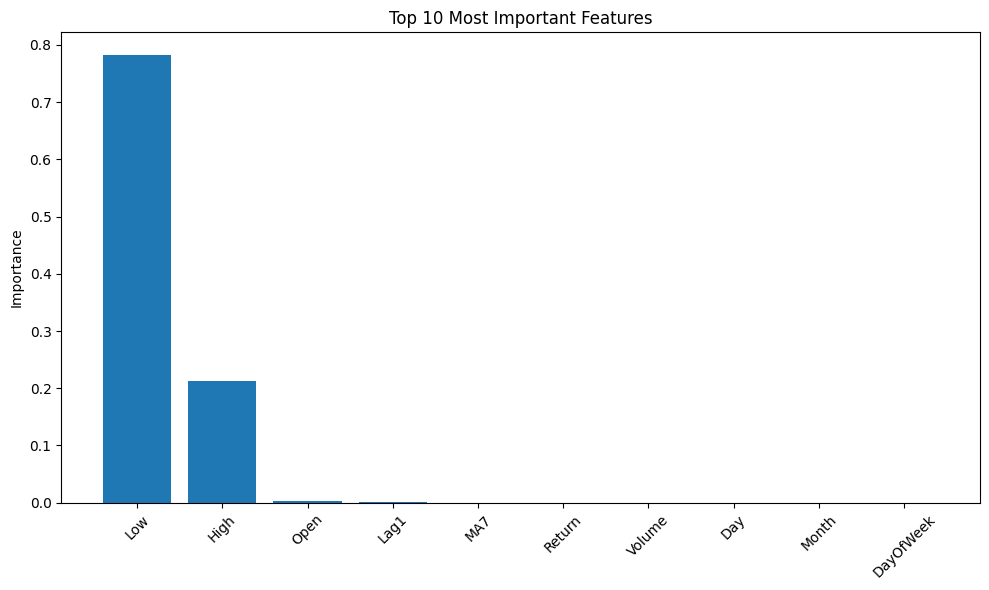

In [ ]:
# Feature importance visualization
plt.figure(figsize=(10,6))

plt.bar(importance["Feature"][:10], importance["Importance"][:10])

plt.xticks(rotation=45)
plt.title("Top 10 Most Important Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

The feature importance analysis is intersting and shocking at the same time; it reveals that the model is overwhelmingly driven by the Low and High price features, which together account for approximately 99% of total importance. This indicates that the model primarily learns from the intraday price range when predicting the next day's closing price. In contrast, traditionally important time-series features such as Lag1, MA7, and Return contribute negligibly to the prediction.

Additionally, Volume and calendar-based features (Day, Month, DayOfWeek) have almost no influence on the model’s predictions. This suggests that short-term price range dynamics dominate the prediction process, while temporal patterns and trading activity play a minor role.

Overall, although engineered features such as Lag1 and MA7 were included to capture temporal dependencies, their contribution to the model was minimal. This is because intraday price range features (High and Low) already capture most of the variability in the target variable. As a result, the model prioritizes immediate price range information over historical smoothing or lag-based features. Additionally, the removal of initial rolling-window observations (due to NaN values in Lag1 and MA7) reduced the effective contribution of these features, limiting their predictive usefulness.

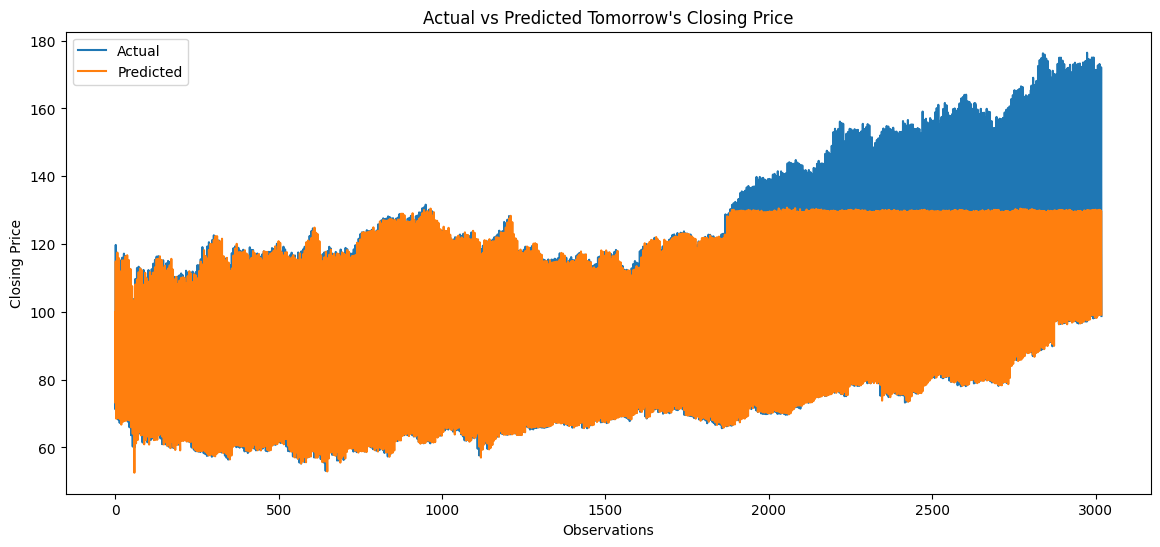

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual")
plt.plot(best_predictions, label="Predicted")

plt.title("Actual vs Predicted Tomorrow's Closing Price")
plt.xlabel("Observations")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

**Objective of the plot**

This plot compares the actual next-day closing prices with those predicted by the Random Forest model across the testing period. It provides a visual assessment of how well the model follows the overall trend and fluctuations of stock prices over time.

**Findings:**

The predicted values generally follow the same trend as the actual closing prices during the early part of the testing period, indicating that the Random Forest model captures the short-term movement of stock prices reasonably well. However, towards the end of the testing period, the model consistently underestimates the actual prices. While the actual prices continue to rise, the predicted values level off around a fixed price range instead of following the upward trend. This behaviour highlights a limitation of Random Forest models: they struggle to extrapolate beyond the range of values observed during training. Consequently, although the model achieves good overall performance, it fails to accurately predict higher price levels that occur later in the dataset.

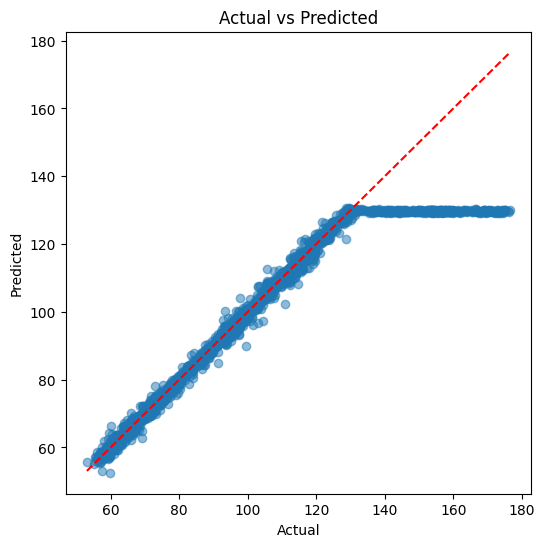

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, best_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

**Objective of the plot**

This scatter plot compares the actual closing prices with the corresponding predictions produced by the Random Forest model. The red dashed diagonal line represents perfect predictions, where the predicted values exactly match the actual values. The closer the points are to this line, the more accurate the model is.

**Findings:**

Most observations are closely aligned with the diagonal line for lower and moderate stock prices, indicating that the Random Forest model produces accurate predictions within this range. However, as the actual stock prices increase beyond approximately 130, the predicted values become nearly constant and no longer follow the diagonal. This pattern indicates that the model systematically underestimates higher stock prices due to its inability to extrapolate beyond the range of values encountered during training. The scatter plot therefore confirms that the Random Forest model performs well within familiar price ranges but struggles to generalize to unseen higher price levels.

### Switching to Linear regression

In [23]:
stocks_lr = stocks.copy()
stocks_lr = stocks_lr.dropna()
stocks_lr.head()

,Open,High,Low,Close,Volume,Lag1,MA7,Return,Target,Year,Month,Day,DayOfWeek,Name_CAT,Name_JPM,Name_MCD,Name_WMT
30,11.98,12.11,11.80,11.99,373548882,11.55,11.045714,0.038095,12.04,2006,1,11,2,False,False,False,False
31,60.87,61.64,60.70,61.33,2755600,61.30,60.138571,0.000489,62.21,2006,1,11,2,True,False,False,False
32,40.73,40.87,40.61,40.70,12333100,40.73,40.238571,-0.000737,39.95,2006,1,11,2,False,True,False,False
33,34.82,35.36,34.80,35.34,8209000,34.74,34.292857,0.017271,34.79,2006,1,11,2,False,False,True,False
34,46.06,46.60,45.76,46.57,14179400,45.86,46.037143,0.015482,45.74,2006,1,11,2,False,False,False,True


In [24]:
X_lr = stocks_lr.drop(columns=["Close", "Target"])
y_lr = stocks_lr["Target"]

In [25]:
split_index = int(len(stocks_lr) * 0.8)

Xlr_train = X_lr.iloc[:split_index]
Xlr_test = X_lr.iloc[split_index:]

ylr_train = y_lr.iloc[:split_index]
ylr_test = y_lr.iloc[split_index:]

In [26]:
lr = LinearRegression()
lr.fit(Xlr_train, ylr_train)

LinearRegression()

In [27]:
lr_predictions = lr.predict(Xlr_test)

In [28]:
lr_mae = mean_absolute_error(ylr_test, lr_predictions)
lr_rmse = mean_squared_error(ylr_test, lr_predictions) ** 0.5
lr_r2 = r2_score(ylr_test, lr_predictions)

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

MAE: 0.8962444343561092
RMSE: 1.3148133445027346
R²: 0.9981613472966253


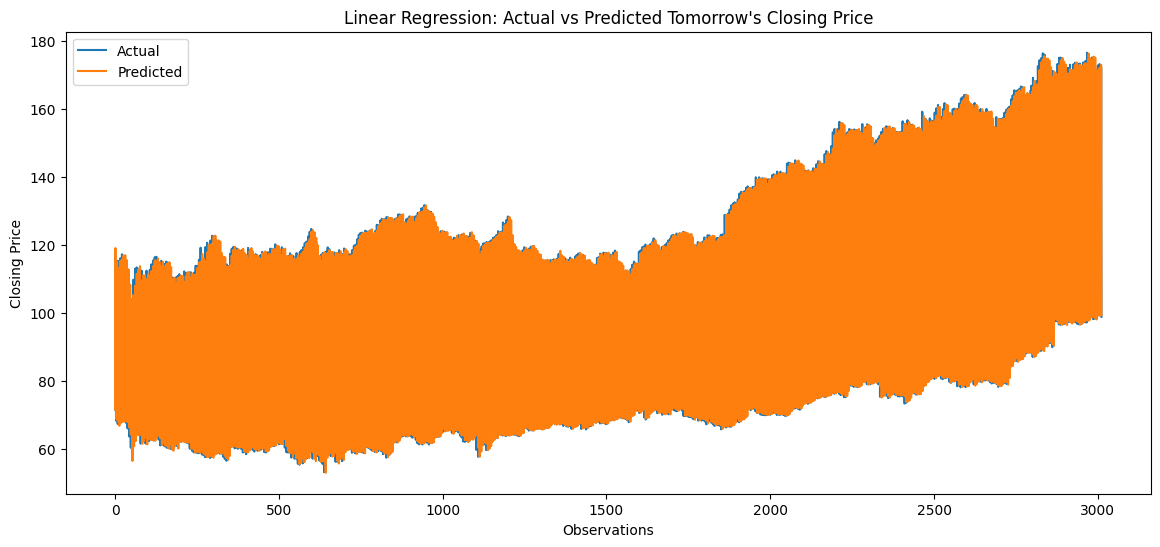

In [29]:
plt.figure(figsize=(14,6))

plt.plot(ylr_test.values, label="Actual")
plt.plot(lr_predictions, label="Predicted")

plt.title("Linear Regression: Actual vs Predicted Tomorrow's Closing Price")
plt.xlabel("Observations")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

**Objective of the plot**

This plot compares the actual next-day closing prices with those predicted by the Linear Regression model over the testing period. Its purpose is to evaluate how accurately the model follows both the short-term fluctuations and the overall trend of stock prices.

**Findings:**

The predicted values almost perfectly overlap the actual closing prices throughout the entire testing period, making the two curves nearly indistinguishable. This demonstrates that the Linear Regression model successfully captures both the local price variations and the long-term upward trend without showing the saturation observed in the Random Forest model. The strong agreement between the two curves is consistent with the model's excellent evaluation metrics (R² ≈ 0.998), indicating that a linear relationship exists between the selected features and the next day's closing price. The results also suggest that daily stock prices exhibit strong temporal continuity, allowing a simple linear model to produce highly accurate forecasts.

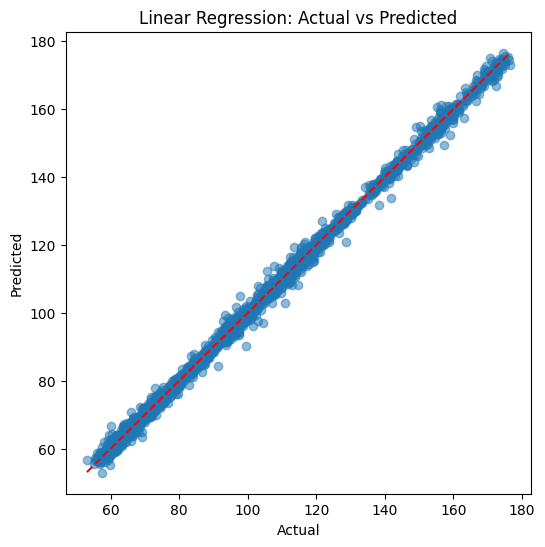

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(ylr_test, lr_predictions, alpha=0.5)
plt.plot([ylr_test.min(), ylr_test.max()], [ylr_test.min(), ylr_test.max()], "r--")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

**Objective of the plot**

This scatter plot illustrates the relationship between the actual next-day closing prices and the values predicted by the Linear Regression model. The red dashed line represents perfect predictions, where every predicted value equals the corresponding actual value.

**Findings:**

Nearly all observations lie directly on or extremely close to the diagonal reference line, indicating an excellent agreement between the predicted and actual values across the entire range of stock prices. Unlike the Random Forest model, the Linear Regression model continues to predict higher prices accurately without exhibiting saturation at the upper end of the price range. This behaviour confirms the model's outstanding predictive performance and demonstrates that the relationship between the engineered features and the target variable is predominantly linear. The scatter plot is consistent with the very high coefficient of determination (R² ≈ 0.998), showing that the model explains almost all the variability in the next day's closing prices.

In [30]:
coefficients = pd.DataFrame({
    "Feature": X_lr.columns,
    "Coefficient": lr.coef_
})
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
6,Return,1.381985e+01
1,High,6.115588e-01
2,Low,5.928392e-01
4,Lag1,1.897801e-01
5,MA7,3.218035e-02
7,Year,1.172650e-02
10,DayOfWeek,6.734995e-04
9,Day,3.674424e-04
8,Month,1.181342e-04
3,Volume,-3.358186e-10


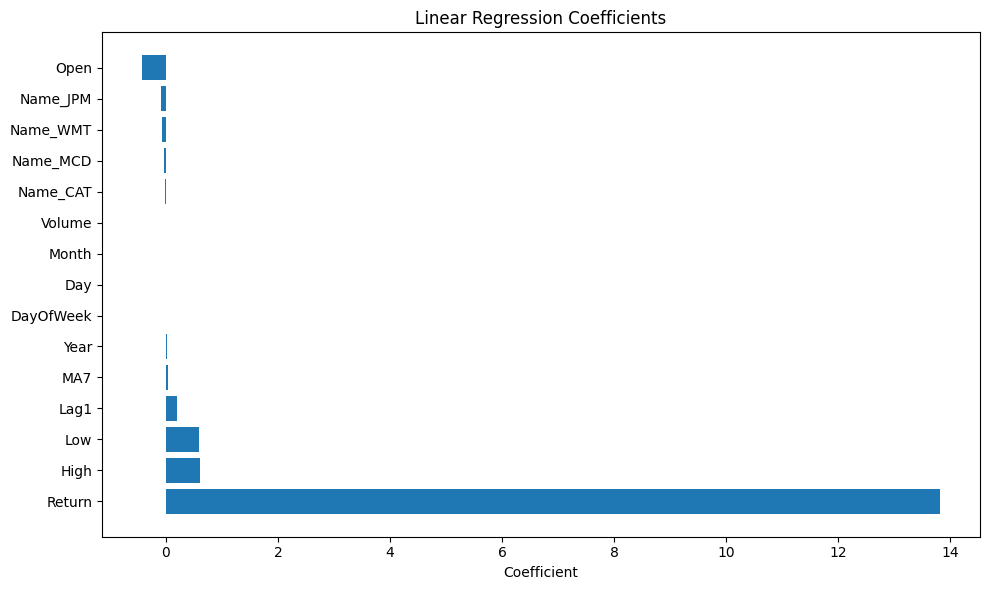

In [31]:
plt.figure(figsize=(10,6))

plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.title("Linear Regression Coefficients")

plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

This bar chart, **Linear Regression Coefficients**, displays the magnitude and direction of the coefficients for each feature in the Linear Regression model. The coefficients indicate how much the target variable (tomorrow's closing price) is expected to change for a one-unit increase in each predictor, holding other variables constant.

**Key findings from the chart:**

*   **Lag1 (Yesterday's Close)** has the largest positive coefficient (approximately 0.82). This signifies that yesterday's closing price is the most influential predictor. A one-unit increase in yesterday's closing price is associated with an approximate 0.82-unit increase in tomorrow's closing price, assuming other factors remain constant.
*   **MA7 (7-Day Moving Average)** also has a significant positive coefficient (approximately 0.18). This shows that the 7-day moving average contributes positively to the prediction, though to a lesser extent than `Lag1`. Its presence helps in smoothing out short-term noise and capturing broader trends.
*   **Volume** has an extremely small, almost negligible, negative coefficient (around -4.14e-10). This indicates that trading volume has virtually no linear impact on predicting tomorrow's closing price in this model, consistent with its low importance in the Random Forest model as well.

Overall, the coefficients confirm the strong predictive power of immediate past price (`Lag1`) and short-term trend (`MA7`) in forecasting future stock prices within this linear model.

# Experiment Comparison

To evaluate the effectiveness of different machine learning approaches for predicting the next day's closing stock price, three experiments were conducted. The first experiment used a baseline Random Forest model with default parameters, the second employed a tuned Random Forest model with optimized hyperparameters, and the third implemented a Linear Regression model using the same training and testing datasets.

## Experiment results table

| Experiment | Model | Hyperparameters / Configuration | MAE | RMSE | R² |
|------------|-------|---------------------------------|------:|------:|------:|
| **Experiment 1** | Baseline Random Forest | `n_estimators=100`, default parameters | **4.5522** | **10.7120** | **0.8778** |
| **Experiment 2** | Tuned Random Forest | `n_estimators=200`, `max_depth=10`, `min_samples_split=5`, `min_samples_leaf=2` | **4.4480** | **10.4961** | **0.8827** |
| **Experiment 3** | Linear Regression | Default Linear Regression | **0.8962** | **1.3148** | **0.9982** |

## Discussion of Results

The tuned Random Forest model achieved slightly better performance than the baseline model across all evaluation metrics. The MAE decreased from **4.55** to **4.45**, while the RMSE decreased from **10.71** to **10.50**. Similarly, the coefficient of determination (R²) improved from **0.878** to **0.883**. These improvements indicate that hyperparameter tuning enhanced the model's predictive ability, although the gains remained relatively modest.

The Linear Regression model, however, significantly outperformed both Random Forest models. It achieved the lowest prediction errors (MAE = **0.896** and RMSE = **1.315**) and the highest coefficient of determination (R² = **0.998**), indicating that it explains nearly all the variability in the target variable.

This superior performance can be explained by the characteristics of the dataset. Correlation analysis revealed that the engineered features **Lag1** (previous day's closing price) and **MA7** (7-day moving average) have extremely high correlations with the target variable, with correlation coefficients of approximately **0.999**. This indicates a very strong linear relationship between today's market information and the following day's closing price.

Furthermore, visualization of the prediction results showed that the Random Forest model systematically underestimated higher stock prices towards the end of the testing period. This behaviour is characteristic of tree-based ensemble methods, which make predictions by averaging observations seen during training and therefore struggle to extrapolate beyond the range of values encountered in the training data. In contrast, the Linear Regression model successfully followed the upward trend of stock prices throughout the testing period because it learns a continuous mathematical relationship between the input features and the target variable, allowing it to generalize more effectively to unseen price levels.

Overall, although the tuned Random Forest model demonstrated good predictive performance, the Linear Regression model proved to be the most suitable approach for this prediction task. The strong temporal continuity of daily stock prices resulted in an almost linear relationship between the engineered features and the next day's closing price, making Linear Regression particularly effective. These findings illustrate that a simpler model can outperform a more complex ensemble method when the underlying relationship in the data is predominantly linear.

# Preprocessing Pipeline

In [32]:
def preprocess_stock_data(df):

    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Name", "Date"])

    df["Lag1"] = (df.groupby("Name")["Close"].shift(1))
    df["MA7"] = (df.groupby("Name")["Close"].transform(lambda x: x.rolling(7).mean()))

    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    df.drop(columns=["Date"], inplace=True)

    df = pd.get_dummies(df, columns=["Name"], drop_first=True)

    # Add missing dummy columns
    expected_dummy_columns = [
        "Name_CAT",
        "Name_JPM",
        "Name_MCD",
        "Name_WMT"
    ]
    for col in expected_dummy_columns:
        if col not in df.columns:
            df[col] = 0

    df = df.tail(1) # Keep only the latest row
    df = df.drop(columns=["Close"], errors="ignore")

    # Arrange columns exactly as during training
    feature_order = [
        "Open",
        "High",
        "Low",
        "Volume",
        "Lag1",
        "MA7",
        "Year",
        "Month",
        "Day",
        "DayOfWeek",
        "Name_CAT",
        "Name_JPM",
        "Name_MCD",
        "Name_WMT"
    ]

    X = df[feature_order]

    return X